In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

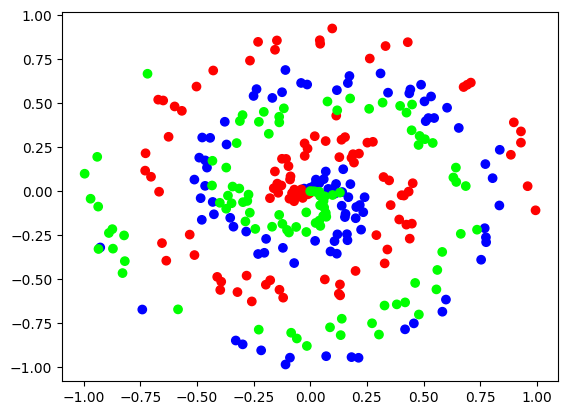

In [37]:
# creating the datas
! pip install nnfs

np.random_state = 42
from nnfs.datasets import spiral_data
X ,y = spiral_data(100,3)

plt.scatter(X[:,0],X[:,1],c=y,cmap='brg')

In [38]:
# class implementing the dense layers
class DenseLayer:
  def __init__(self,n_inputs,n_neurons) -> None:
    self.weights = 0.1 * np.random.randn(n_inputs,n_neurons)
    self.bias = np.zeros((1,n_neurons))

  def forward(self,X):
    self.inputs = X
    self.output = self.inputs@self.weights + self.bias
    return self.output

  def backward(self,dvalues):
    self.dweights = self.inputs.T @ dvalues
    self.dbias = np.sum(dvalues,axis=0,keepdims=True)
    self.dinputs = dvalues@self.weights.T

In [39]:
# class implementing Relu activation
class ReLU:
  def forward(self,inputs):
    self.inputs = inputs
    self.output = np.maximum(0,self.inputs)
  def backward(self,dvalues):
    relu_derivative =  np.where(self.inputs>0,1,0)
    self.dinputs = dvalues * relu_derivative
    return self.dinputs


In [40]:
# class implementing Softmax and Categorical cross entropy

class SoftmaxCrossEntropy:
  def SoftMax_forward(self,weighted_sum):   # this makes the predictions : e^z1 / e^z1 + e^z2 + e^z3
    # subtract the maximum of each row from each number
    shifted = weighted_sum - np.max(weighted_sum ,axis =1 , keepdims = True)
    # get exponents of each value
    exp_weighted_sum = np.exp(shifted)
    self.output =  exp_weighted_sum / np.sum(exp_weighted_sum,axis=1,keepdims=True)
    return self.output

  def CC_forward(self,softmax_output,true_labels):    # this gets the loss : categorical cross entropy -> summation yilog(yi_hat)
    # convert the true_labels into one hot encoding if not given
    samples,classes = softmax_output.shape
    if len(true_labels.shape)==1:
      true_labels = np.eye(classes)[true_labels]
    # clip to prevent log(0)
    clipped = np.clip(softmax_output,1e-7,1-1e-7)
    corrected_confidence = np.sum(clipped*true_labels,axis=1)
    negative_log_likelihood = -np.log(corrected_confidence)
    return np.mean(negative_log_likelihood)

  def backward(self,y_true,y_pred):
    # partial differentiation of the loss wrt the weights (DL_Dz) is given by y_True-y_pred
    samples  = y_pred.shape[0]
    classes = y_pred.shape[1]
    if len(y_true.shape) == 1 : # ohe the true matrix , if not
      y_true = np.eye(classes)[y_true]
    Dloss_Dz = y_pred - y_true    # dloss_dz is the difference of the pred and true
    Dloss_Dz /= samples  # divide by number of samples to normalize
    return Dloss_Dz


In [41]:
# implementing the optimizers : Batch gradient descent , learning rate decay , momentum

class gd_decay_momentum_optimizer:
  def __init__(self,learning_rate=1.0,decay =0.0,momentum = 0.0):
    self.initial_lr = learning_rate
    self.lr = learning_rate
    self.decay = decay
    self.momentum = momentum
    self.t = 0

  def update_lr(self):
    if self.decay :
      self.lr = self.initial_lr/(1+self.decay*self.t)
    self.t+=1

  def update_parameters(self,layer):
    # if we use momentum
    if self.momentum:
      # wt = wt-1 - self.decay*(layer.dweights) + (self.momentum * velocity)     velocity = previous weight updates
      if not hasattr(layer,'weight_momentum'):
        # for each layer , before the first update there are no previous weight updates , hence the weight and bias momentum initially is a matrix of 0s
        layer.weight_momentum = np.zeros_like(layer.weights)
        layer.bias_momentum = np.zeros_like(layer.bias)

      # updating
      weight_update = self.momentum * layer.weight_momentum - self.lr*layer.dweights
      layer.weight_momentum = weight_update

      bias_update = self.momentum*layer.bias_momentum - self.lr*layer.dbias
      layer.bias_momentum = bias_update

    else:
      # use the vanilla gradient descent's update rule
      weight_update = -self.lr*layer.dweights
      bias_update = -self.lr*layer.dbias

    # update
    layer.weights+=weight_update
    layer.bias += bias_update

In [42]:
# adagrad class

# The performance of adagrad is not that great as the update in the weight stops or happens by a very very small value after a point
# this happens due to the increased value of cache in the denominator , due to which the update paramter never changes
# and hence the original parameters never change

class adagrad_optimizer:
  def __init__(self,learning_rate=1.0,decay=0.0,epsilon=1e-7) -> None:
    self.initial_lr = learning_rate
    self.lr = learning_rate
    self.decay = decay
    self.iterations = 0
    self.epsilon= epsilon   # constant term to avoid division by 0

  def pre_update(self):
    # decaying lr
    if self.decay:
      self.lr = self.initial_lr/(1+self.decay*self.iterations)

  def update_parameters(self,layer):
    # intialize the cache to store the update history of parameters
    if not hasattr(layer,'weight_cache'):
      layer.weight_cache = np.zeros_like(layer.weights)
      layer.bias_cache = np.zeros_like(layer.bias)

    layer.weight_cache += (layer.dweights)**2   # add the square of the current gradients in the cache
    layer.bias_cache += (layer.dbias)**2

    # update parameters
    weight_update = -self.lr * layer.dweights/np.sqrt(layer.weight_cache+self.epsilon)
    bias_update = -self.lr*layer.dbias / np.sqrt(layer.bias_cache+self.epsilon)


    # update
    layer.weights+=weight_update
    layer.bias += bias_update

  def post_update(self):
    # increment the iteration
    self.iterations+=1

In [43]:
# rmsprop optimizer
class rmsprop_optimizer:
  def __init__(self,learning_rate=0.001,decay=0.0,epsilon=1e-7,rho=0.9) -> None:
    self.initial_lr = learning_rate
    self.lr = learning_rate
    self.decay = decay
    self.iterations = 0
    self.epsilon= epsilon   # constant term to avoid division by 0
    self.rho = rho          # hyperparameter in the cache equation of rms prop

  def pre_update(self):
    # decaying lr
    if self.decay:
      self.lr = self.initial_lr/(1+self.decay*self.iterations)

  def update_parameters(self,layer):
    # intialize the cache to store the update history of parameters
    if not hasattr(layer,'weight_cache'):
      layer.weight_cache = np.zeros_like(layer.weights)
      layer.bias_cache = np.zeros_like(layer.bias)

    layer.weight_cache = self.rho*layer.weight_cache + (1-self.rho)*(layer.dweights)**2
    layer.bias_cache = self.rho*layer.bias_cache + (1-self.rho)*(layer.dbias)**2

    # update parameters
    weight_update = -self.lr * layer.dweights/np.sqrt(layer.weight_cache+self.epsilon)
    bias_update = -self.lr*layer.dbias / np.sqrt(layer.bias_cache+self.epsilon)

    # update
    layer.weights+=weight_update
    layer.bias += bias_update

  def post_update(self):
    # increment the iteration
    self.iterations+=1


In [44]:
class AdamOptimizer:
    def __init__(self, learning_rate=0.001, decay=0.0, epsilon=1e-7, b1=0.9, b2=0.999):
        self.learning_rate = learning_rate
        self.lr = learning_rate
        self.initial_lr = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.beta1 = b1
        self.beta2 = b2

    def pre_update(self):
        if self.decay:
            self.lr = self.initial_lr / (1 + self.decay * self.iterations)

    def update_parameters(self, layer):

        # Initialize
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.bias)

            layer.weight_momentum = np.zeros_like(layer.weights)
            layer.bias_momentum = np.zeros_like(layer.bias)

        #Update momentum
        layer.weight_momentum = (
            self.beta1 * layer.weight_momentum +
            (1 - self.beta1) * layer.dweights
        )

        layer.bias_momentum = (
            self.beta1 * layer.bias_momentum +
            (1 - self.beta1) * layer.dbias
        )

        # Update cache
        layer.weight_cache = (
            self.beta2 * layer.weight_cache +
            (1 - self.beta2) * (layer.dweights ** 2)
        )

        layer.bias_cache = (
            self.beta2 * layer.bias_cache +
            (1 - self.beta2) * (layer.dbias ** 2)
        )

        #
        t = self.iterations + 1

        m_hat_w = layer.weight_momentum / (1 - self.beta1 ** t)
        m_hat_b = layer.bias_momentum / (1 - self.beta1 ** t)

        v_hat_w = layer.weight_cache / (1 - self.beta2 ** t)
        v_hat_b = layer.bias_cache / (1 - self.beta2 ** t)

        #
        layer.weights -= self.lr * (m_hat_w / (np.sqrt(v_hat_w) + self.epsilon))
        layer.bias -= self.lr * (m_hat_b / (np.sqrt(v_hat_b) + self.epsilon))

    def post_update(self):
        self.iterations += 1

In [46]:
# creating the model
dense1 = DenseLayer(2,64)
dense2 = DenseLayer(64,3)
relu = ReLU()
sce = SoftmaxCrossEntropy()
#opt = Optimizer(decay=1e-3,momentum=0.9)    # add a decay rate
#opt = adagrad_optimizer(decay=1e-4)
#opt = rmsprop_optimizer(learning_rate=0.001,decay=1e-5,rho=0.9)   # rmsprop's better performace than adagrad can be seen only when we implement it on larger epochs
opt = AdamOptimizer(learning_rate=0.02,decay=1e-5)
for i in range(10001):
  # forward pass
  dense1.forward(X)
  relu.forward(dense1.output)
  dense2.forward(relu.output)
  y_pred = sce.SoftMax_forward(dense2.output)

  loss = sce.CC_forward(y_pred,y)

  # backward pass
  dloss_dz2 = sce.backward(y,y_pred) # derivative of the loss wrt z2 (z2 is the input to 2nd dense layer) , so this calcultes DLoss
  dense2.backward(dloss_dz2)
  dloss_dz1 = relu.backward(dense2.dinputs)
  dense1.backward(dloss_dz1)

  # vanilla gd for updating
  #gd.update_parameters(dense1)
  #gd.update_parameters(dense2)

  opt.pre_update() # using decaying learning rate
  opt.update_parameters(dense1)
  opt.update_parameters(dense2)
  opt.post_update()

  if i % 100 == 0:
    predictions = np.argmax(y_pred, axis=1)
    acc = np.mean(predictions == y)
    print(f"epoch : {i},Loss: {loss:.4f}, Acc: {acc:.4f} , lr : {opt.lr}")




epoch : 0,Loss: 1.1013, Acc: 0.3667 , lr : 0.02
epoch : 100,Loss: 0.7390, Acc: 0.7400 , lr : 0.019980019980019983
epoch : 200,Loss: 0.4784, Acc: 0.8300 , lr : 0.01996007984031936
epoch : 300,Loss: 0.3573, Acc: 0.8900 , lr : 0.019940179461615158
epoch : 400,Loss: 0.2895, Acc: 0.9033 , lr : 0.0199203187250996
epoch : 500,Loss: 0.2396, Acc: 0.9233 , lr : 0.019900497512437814
epoch : 600,Loss: 0.2074, Acc: 0.9367 , lr : 0.019880715705765408
epoch : 700,Loss: 0.1838, Acc: 0.9433 , lr : 0.0198609731876862
epoch : 800,Loss: 0.1658, Acc: 0.9600 , lr : 0.01984126984126984
epoch : 900,Loss: 0.1533, Acc: 0.9533 , lr : 0.019821605550049557
epoch : 1000,Loss: 0.1445, Acc: 0.9500 , lr : 0.019801980198019802
epoch : 1100,Loss: 0.1375, Acc: 0.9533 , lr : 0.019782393669634028
epoch : 1200,Loss: 0.1315, Acc: 0.9600 , lr : 0.019762845849802372
epoch : 1300,Loss: 0.1270, Acc: 0.9600 , lr : 0.01974333662388944
epoch : 1400,Loss: 0.1237, Acc: 0.9567 , lr : 0.01972386587771203
epoch : 1500,Loss: 0.1201, Acc:

RESULT of ADAM optimizer : epoch : 10000,Loss: 0.0699, Acc: 0.9767 , lr : 0.01818181818181818